# Fake News Detection




## Objective


The objective of this assignment is to develop a Semantic Classification model. You will be using Word2Vec method to extract the semantic relations from the text and develop a basic understanding of how to train supervised models to categorise text based on its meaning, rather than just syntax. You will explore how this technique is used in situations where understanding textual meaning plays a critical role in making accurate and efficient decisions.


## Business Objective

The spread of fake news has become a significant challenge in today’s digital world. With the massive volume of news articles published daily, it’s becoming harder to distinguish between credible and misleading information. This creates a need for systems that can automatically classify news articles as true or fake, helping to reduce misinformation and protect public trust.


In this assignment, you will develop a Semantic Classification model that uses the Word2Vec method to detect recurring patterns and themes in news articles. Using supervised learning models, the goal is to build a system that classifies news articles as either fake or true.


<h2> Pipelines that needs to be performed </h2>

You need to perform the following tasks to complete the assignment:

<ol type="1">

  <li> Data Preparation
  <li> Text Preprocessing
  <li> Train Validation Split
  <li> EDA on Training Data
  <li> EDA on Validation Data [Optional]
  <li> Feature Extraction
  <li> Model Training and Evaluation

</ol>

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Dictionary


For this assignment, you will work with two datasets, `True.csv` and `Fake.csv`.
Both datasets contain three columns:
<ul>
  <li> title of the news article
  <li> text of the news article
  <li> date of article publication
</ul>

`True.csv` dataset includes 21,417 true news, while the `Fake.csv` dataset comprises 23,502 fake news.

## Installing required Libraries

In [1]:
!pip install --upgrade numpy==1.26.4
!pip install --upgrade pandas==2.2.2
!pip install --upgrade nltk==3.9.1
!pip install --upgrade spacy==3.7.5
!pip install --upgrade scipy==1.12
!pip install --upgrade pydantic==2.10.5
!pip install wordcloud==1.9.4
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 11.6 MB/s eta 0:00:00a 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## Importing the necessary libraries

In [3]:
# Import essential libraries for data manipulation and analysis
import numpy as np  # For numerical operations and arrays
import pandas as pd  # For working with dataframes and structured data
import re  # For regular expression operations (text processing)
import nltk  # Natural Language Toolkit for text processing
import spacy  # For advanced NLP tasks
import string  # For handling string-related operations

# Optional: Uncomment the line below to enable GPU support for spaCy (if you have a compatible GPU)
#spacy.require_gpu()

# Load the spaCy small English language model
nlp = spacy.load("en_core_web_sm")

# For data visualization
import seaborn as sns  # Data visualization library for statistical graphics
import matplotlib.pyplot as plt  # Matplotlib for creating static plots
# Configure Matplotlib to display plots inline in Jupyter Notebook
%matplotlib inline

# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# For interactive plots
from plotly.offline import plot  # Enables offline plotting with Plotly
import plotly.graph_objects as go  # For creating customizable Plotly plots
import plotly.express as px  # A high-level interface for Plotly

# For preprocessing and feature extraction in machine learning
from sklearn.feature_extraction.text import (  # Methods for text vectorization
    CountVectorizer,  # Converts text into a bag-of-words model
)

# Import accuracy, precision, recall, f_score from sklearn to predict train accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Pretty printing for better readability of output
from pprint import pprint

# For progress tracking in loops (useful for larger datasets)
from tqdm import tqdm, tqdm_notebook  # Progress bar for loops
tqdm.pandas()  # Enables progress bars for pandas operations


In [5]:
## Change the display properties of pandas to max
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Load the data

Load the True.csv and Fake.csv files as DataFrames

In [7]:
# Import the first file - True.csv
data_true=pd.read_csv('True.csv')
# Import the second file - Fake.csv
data_fake=pd.read_csv('Fake.csv')


## **1.** Data Preparation  <font color = red>[10 marks]</font>





### **1.0** Data Understanding

In [9]:
# Inspect the DataFrame with True News to understand the given data
data_true.head()

title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [12]:
# Inspect the DataFrame with Fake News to understand the given data
data_fake.head()

,title,text,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31, 2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down. Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images.","December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens, the dossier is not what started the investigation, according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that, Papadopoulos wasn t just a covfefe boy for Trump, as his administration has alleged. He had a much larger role, but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known before that the former

In [14]:
# Print the column details for True News DataFrame
data_true.info()
print("#"*70)
data_true.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   21417 non-null  object
 1   text    21417 non-null  object
 2   date    21417 non-null  object
dtypes: object(3)
memory usage: 502.1+ KB
######################################################################


,title,text,date
count,21417,21417,21417
unique,20826,21192,716
top,Factbox: Trump fills top jobs for his administration,"(Reuters) - Highlights for U.S. President Donald Trump’s administration on Thursday: The United States drops a massive GBU-43 bomb, the largest non-nuclear bomb it has ever used in combat, in Afghanistan against a series of caves used by Islamic State militants, the Pentagon says. Trump says Pyongyang is a problem that “will be taken care of” amid speculation that North Korea is on the verge of a sixth nuclear test. Military force cannot resolve tension over North Korea, China warns, while an influential Chinese newspaper urges Pyongyang to halt its nuclear program in exchange for Beijing’s protection. The Trump administration is focusing its North Korea strategy on tougher economic sanctions, possibly including intercepting cargo ships and punishing Chinese banks doing business with Pyongyang, U.S. officials say. Trump says “things will work out fine” between the United States and Russia, a day after declaring U.S.-Russian relations may be at an all-time low. Trump signals he could be moving closer to the mainstream on monetary policy, saying he has not ruled out reappointment of Janet Yellen as Federal Reserve chair as he considers his choices for the U.S. central bank. [nL1N1HL14B] Trump signs a resolution that will allow U.S. states to restrict how federal funds for contraception and reproductive health are spent, a move cheered by anti-abortion campaigners. Democratic Senator Chris Van Hollen presses Deutsche Bank to release information about issues including Trump’s debt and any bank meetings with Trump administration officials, saying he has “great concern” about possible conflicts of interest. EXPORT-IMPORT BANK Trump’s office says he plans to revive the hobbled Export-Import Bank of the United States, a victory for American manufacturers such as Boeing Co and General Electric Co that have overseas customers that use the agency’s government-backed loans to purchase their products. Top Wall Street bankers say they are having positive discussions about financial regulation in Washington, and downplay the idea U.S. policymakers may force their institutions to split up. The United States is pushing for trade to be a key issue in top-level economic talks with Japan, a source says, an unwelcome development for Tokyo, which is seeking to fend off U.S. pressure to reduce the bilateral trade imbalance. Trump’s administration has focused on one group of illegal immigrants more than others: women with children, according to eight Department of Homeland Security officials interviewed by Reuters about agency planning.","December 20, 2017"
freq,14,8,182


In [16]:
# Print the column details for Fake News Dataframe
data_fake.info()
print("#"*70)
data_fake.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23523 entries, 0 to 23522
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   23502 non-null  object
 1   text    23502 non-null  object
 2   date    23481 non-null  object
dtypes: object(3)
memory usage: 551.4+ KB
######################################################################


In [20]:
# Print the column names of both DataFrames
print(data_true.columns)
print(data_fake.columns)

Index(['title', 'text', 'date'], dtype='object')
Index(['title', 'text', 'date'], dtype='object')


### **1.1** Add new column  <font color = red>[3 marks]</font> <br>

Add new column `news_label` to both the DataFrames and assign labels

In [22]:
# Add a new column 'news_label' to the true news DataFrame and assign the label "1" to indicate that these news are true
data_true['news_label'] = 1
# Add a new column 'news_label' to the fake news DataFrame and assign the label "0" to indicate that these news are fake
data_fake['news_label'] = 0

### **1.2** Merge DataFrames  <font color = red>[2 marks]</font> <br>

Create a new Dataframe by merging True and Fake DataFrames

In [24]:
# Combine the true and fake news DataFrames into a single DataFrame
true_fake_dataset = pd.concat([data_true, data_fake], axis=0)
true_fake_dataset.head(5)

title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [26]:
# Display the first 5 rows of the combined DataFrame to verify the result
print(true_fake_dataset["news_label"].value_counts())

news_label
0    23523
1    21417
Name: count, dtype: int64


### **1.3** Handle the null values  <font color = red>[2 marks]</font> <br>

Check for null values and handle it by imputation or dropping the null values

In [28]:
# Check Presence of Null Values
true_fake_dataset.isnull().sum()

title         21
text          21
date          42
news_label     0
dtype: int64

In [32]:
# Handle Rows with Null Values
true_fake_dataset = true_fake_dataset.dropna()
true_fake_dataset.isnull().sum()

title         0
text          0
date          0
news_label    0
dtype: int64

### **1.4** Merge the relevant columns and drop the rest from the DataFrame  <font color = red>[3 marks]</font> <br>

Combine the relevant columns into a new column `news_text` and then drop irrelevant columns from the DataFrame

In [34]:
# Combine the relevant columns into a new column 'news_text' by joining their values with a space
true_fake_dataset['news_text'] = true_fake_dataset['title'].astype(str) + ' ' + true_fake_dataset['text'].astype(str)
# Drop the irrelevant columns from the DataFrame as they are no longer needed
true_fake_dataset=true_fake_dataset.drop(['title','date', 'text'], axis = 1)
# Display the first 5 rows of the updated DataFrame to check the result
true_fake_dataset.head(5)

news_label  \
0           1   
1           1   
2           1   
3           1   
4           1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

## **2.** Text Preprocessing <font color = red>[15 marks]</font> <br>






On all the news text, you need to:
<ol type=1>
  <li> Make the text lowercase
  <li> Remove text in square brackets
  <li> Remove punctuation
  <li> Remove words containing numbers
</ol>


Once you have done these cleaning operations you need to perform POS tagging and lemmatization on the cleaned news text, and remove all words that are not tagged as NN or NNS.

### **2.1** Text Cleaning  <font color = red>[5 marks]</font> <br>



#### 2.1.0 Create a new DataFrame to store the processed data



In [43]:
# Create a DataFrame('df_clean') that will have only the cleaned news text and the lemmatized news text with POS tags removed
df_clean = true_fake_dataset.sample(frac = 1)
# Add 'news_label' column to the new dataframe for topic identification
true_fake_dataset["news_label"].value_counts() # This done one step 1, so column is already present.

news_label
0    23481
1    21417
Name: count, dtype: int64

#### 2.1.1 Write the function to clean the text and remove all the unnecessary elements  <font color = red>[4 marks]</font> <br>



In [48]:
# Write the function here to clean the text and remove all the unnecessary elements
def text_cleanup(text):
# Convert to lower case
    text = text.lower() # this conver uppercase to lower case 
# Remove text in square brackets
    text = re.sub('\[.*?\]','',text) # this will remove square brackets and content within
# Remove punctuation
    text = re.sub("\\W"," ",text) # this will remove square brackets and content within
    text = re.sub('https?://\S+|www\.\S+','',text) # this will remove urls 
    text = re.sub('<.*?>+','',text) # this will remove html tags if any
    text = re.sub('[%s]' % re.escape(string.punctuation),'',text) # this will remove punctuation
# Remove words with numbers
    text = re.sub('\w*\d\w*','',text)  # This will remove words with numbers
    return text

#### 2.1.2  Apply the function to clean the news text and store the cleaned text in a new column within the new DataFrame. <font color = red>[1 mark]</font> <br>


In [101]:
# Apply the function to clean the news text and remove all unnecessary elements
# Store it in a separate column in the new DataFrame
df_clean['cleaned_text'] = df_clean['news_text'].apply(text_cleanup)
df_clean.head(2) 

,news_label,news_text,cleaned_text,processed_text
0,1,"U.N. agrees international experts to probe Yemen war crimes GENEVA (Reuters) - The United Nations agreed on Friday to establish a group of eminent experts to examine all human rights violations commmitted in Yemen s war and to identify those responsible. In a last-minute compromise hammered out between Western powers and Arab countries, the U.N. Human Rights Council adopted by consensus without a vote a resolution which the Yemen delegation said it accepted. A credible international investigation is necessary in order to comprehensively, transparently, independently and impartially establish facts and circumstances surrounding violations with a view to put an end to the cycle of impunity in Yemen, the Dutch delegate told the forum on behalf of a core group of Western states. (This version of the story corrects second paragraph to say adopted without a vote, not with a vote).",u n agrees international experts to probe yemen war crimes geneva reuters the united nations agreed on friday to establish a group of eminent experts to examine all human rights violations commmitted in yemen s war and to identify those responsible in a last minute compromise hammered out between western powers and arab countries the u n human rights council adopted by consensus without a vote a resolution which the yemen delegation said it accepted a credible international investigation is necessary in order to comprehensively transparently independently and impartially establish facts and circumstances surrounding violations with a view to put an end to the cycle of impunity in yemen the dutch delegate told the forum on behalf of a core group of western states this version of the story corrects second paragraph to say adopted without a vote not with a vote,"['n', 'expert', 'yemen', 'war', 'crime', 'nation', 'friday', 'group', 'eminent', 'expert', 'right', 'violation', 'yemen', 'war', 'minute', 'compromise', 'power', 'country', 'right', 'council', 'consensus', 'vote', 'resolution', 'yemen', 'delegation', 'investigation', 'order', 'fact', 'circumstance', 'violation', 'view', 'end', 'cycle', 'impunity', 'yemen', 'dutch', 'delegate', 'forum', 'behalf', 'core', 'group', 'state', 'version', 'story', 'paragraph', 'vote', 'vote']"
1,1,"Risk of deeper involvement as U.S. weighs its options in Afghanistan WASHINGTON (Reuters) - As President Donald Trump’s administration drafts an Afghanistan policy, U.S. officials are seeking a way to reverse gains by militant groups without wading deeper into a 15-year-long war that has no end in sight. In the past month, three U.S. service members have been killed in operations against Islamic State militants near Afghanistan’s porous border with Pakistan, where armed groups still find sanctuary.Officially, the U.S.-led international force in Afghanistan ceased combat operations at the end of 2014, but the conflict has proved difficult to exit without risking the overthrow of the government in Kabul. Current and former officials, speaking on the condition of anonymity, said the Trump administration is carrying out an inter-agency review, and while no decision has been made, the discussions revolve around adding 3,000 to 5,000 troops. One of the officials said there is an emphasis on avoiding artificial deadlines. Former President Barack Obama wanted to reduce the number of U.S. troops in Afghanistan before he left office. He had ordered in more troops in 2011 that peaked at about 100,000. Nearly 9,000 U.S. troops remain in Afghanistan; some 7,000 of them train and assist Afghan forces, and about 1,500 are a part of a counter-terrorism unit that mostly targets pockets of al Qaeda and Islamic State fighters, but also engages the Taliban. In February, Army General John Nicholson, the U.S. commander in Afghanistan, said he needs several thousand more international troops to break a stalemate with the Taliban. Some U.S. officials question the benefit of sending more troops to Af

### **2.2** POS Tagging and Lemmatization  <font color = red>[10 marks]</font> <br>



#### 2.2.1 Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags <font color = red>[8 marks]</font> <br>



In [59]:
# Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags
import nltk

# For tokenization
nltk.download('punkt')

# For stopwords
nltk.download('stopwords')

# For lemmatization
nltk.download('wordnet')

# For POS tagging
nltk.download('averaged_perceptron_tagger')

nltk.download('punkt_tab')

from nltk import word_tokenize, pos_tag
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

nltk.download('averaged_perceptron_tagger_eng') #  download only oncw as it will take some time to compelte
print("Downloaded")
def nouns_processing(text):
    stop_words = set(stopwords.words('english')) # removing english stop words
    lemmatizer = WordNetLemmatizer() # doing lemmatization to keep single word variable
    
    # Tokenize and POS tag
    tokens = word_tokenize(text)  # Tekenizing works
    tagged = pos_tag(tokens)  #Doing POS tagging 
    
    # Keeping only NN and NNS, filtered stopwords and lemmatized words
    nouns = [
        lemmatizer.lemmatize(word.lower(), pos='n')
        for word, tag in tagged
        if tag in ('NN', 'NNS') and word.lower() not in stop_words
    ]
    
    return nouns
    
df_clean['processed_text'] = df_clean['cleaned_text'].apply(nouns_processing)

df_clean.head()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/maheshpathak/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maheshpathak/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/maheshpathak/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/maheshpathak/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/maheshpathak/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/maheshpathak/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Downloaded


,news_label,news_text,cleaned_text,processed_text
18634,1,"U.N. agrees international experts to probe Yemen war crimes GENEVA (Reuters) - The United Nations agreed on Friday to establish a group of eminent experts to examine all human rights violations commmitted in Yemen s war and to identify those responsible. In a last-minute compromise hammered out between Western powers and Arab countries, the U.N. Human Rights Council adopted by consensus without a vote a resolution which the Yemen delegation said it accepted. A credible international investigation is necessary in order to comprehensively, transparently, independently and impartially establish facts and circumstances surrounding violations with a view to put an end to the cycle of impunity in Yemen, the Dutch delegate told the forum on behalf of a core group of Western states. (This version of the story corrects second paragraph to say adopted without a vote, not with a vote).",u n agrees international experts to probe yemen war crimes geneva reuters the united nations agreed on friday to establish a group of eminent experts to examine all human rights violations commmitted in yemen s war and to identify those responsible in a last minute compromise hammered out between western powers and arab countries the u n human rights council adopted by consensus without a vote a resolution which the yemen delegation said it accepted a credible international investigation is necessary in order to comprehensively transparently independently and impartially establish facts and circumstances surrounding violations with a view to put an end to the cycle of impunity in yemen the dutch delegate told the forum on behalf of a core group of western states this version of the story corrects second paragraph to say adopted without a vote not with a vote,"[n, expert, yemen, war, crime, nation, friday, group, eminent, expert, right, violation, yemen, war, minute, compromise, power, country, right, council, consensus, vote, resolution, yemen, delegation, investigation, order, fact, circumstance, violation, view, end, cycle, impunity, yemen, dutch, delegate, forum, behalf, core, group, state, version, story, paragraph, vote, vote]"
4025,1,"Risk of deeper involvement as U.S. weighs its options in Afghanistan WASHINGTON (Reuters) - As President Donald Trump’s administration drafts an Afghanistan policy, U.S. officials are seeking a way to reverse gains by militant groups without wading deeper into a 15-year-long war that has no end in sight. In the past month, three U.S. service members have been killed in operations against Islamic State militants near Afghanistan’s porous border with Pakistan, where armed groups still find sanctuary.Officially, the U.S.-led international force in Afghanistan ceased combat operations at the end of 2014, but the conflict has proved difficult to exit without risking the overthrow of the government in Kabul. Current and former officials, speaking on the condition of anonymity, said the Trump administration is carrying out an inter-agency review, and while no decision has been made, the discussions revolve around adding 3,000 to 5,000 troops. One of the officials said there is an emphasis on avoiding artificial deadlines. Former President Barack Obama wanted to reduce the number of U.S. troops in Afghanistan before he left office. He had ordered in more troops in 2011 that peaked at about 100,000. Nearly 9,000 U.S. troops remain in Afghanistan; some 7,000 of them train and assist Afghan forces, and about 1,500 are a part of a counter-terrorism unit that mostly targets pockets of al Qaeda and Islamic State fighters, but also engages the Taliban. In February, Army General John Nicholson, the U.S. commander in Afghanistan, said he needs several thousand more international troops to break a stalemate with the Taliban. Some U.S. officials question the benefit of sending more troops to Afghanistan. To date, more than 2,300 Americans have been killed and over 17,000 wounded 

#### 2.2.2  Apply the POS tagging and lemmatization function to cleaned text and store it in a new column within the new DataFrame. <font color = red>[2 mark]</font> <br>

**NOTE: Store the cleaned text and the lemmatized text with POS tags removed in separate columns within the new DataFrame.**

**This will be useful for analysing character length differences between cleaned text and lemmatized text with POS tags removed during EDA.**


In [63]:
# Apply POS tagging and lemmatization function to cleaned text
# Store it in a separate column in the new DataFrame
df_clean['processed_text'] = df_clean['cleaned_text'].apply(nouns_processing)

# Preview result
df_clean.head()

,news_label,news_text,cleaned_text,processed_text
18634,1,"U.N. agrees international experts to probe Yemen war crimes GENEVA (Reuters) - The United Nations agreed on Friday to establish a group of eminent experts to examine all human rights violations commmitted in Yemen s war and to identify those responsible. In a last-minute compromise hammered out between Western powers and Arab countries, the U.N. Human Rights Council adopted by consensus without a vote a resolution which the Yemen delegation said it accepted. A credible international investigation is necessary in order to comprehensively, transparently, independently and impartially establish facts and circumstances surrounding violations with a view to put an end to the cycle of impunity in Yemen, the Dutch delegate told the forum on behalf of a core group of Western states. (This version of the story corrects second paragraph to say adopted without a vote, not with a vote).",u n agrees international experts to probe yemen war crimes geneva reuters the united nations agreed on friday to establish a group of eminent experts to examine all human rights violations commmitted in yemen s war and to identify those responsible in a last minute compromise hammered out between western powers and arab countries the u n human rights council adopted by consensus without a vote a resolution which the yemen delegation said it accepted a credible international investigation is necessary in order to comprehensively transparently independently and impartially establish facts and circumstances surrounding violations with a view to put an end to the cycle of impunity in yemen the dutch delegate told the forum on behalf of a core group of western states this version of the story corrects second paragraph to say adopted without a vote not with a vote,"[n, expert, yemen, war, crime, nation, friday, group, eminent, expert, right, violation, yemen, war, minute, compromise, power, country, right, council, consensus, vote, resolution, yemen, delegation, investigation, order, fact, circumstance, violation, view, end, cycle, impunity, yemen, dutch, delegate, forum, behalf, core, group, state, version, story, paragraph, vote, vote]"
4025,1,"Risk of deeper involvement as U.S. weighs its options in Afghanistan WASHINGTON (Reuters) - As President Donald Trump’s administration drafts an Afghanistan policy, U.S. officials are seeking a way to reverse gains by militant groups without wading deeper into a 15-year-long war that has no end in sight. In the past month, three U.S. service members have been killed in operations against Islamic State militants near Afghanistan’s porous border with Pakistan, where armed groups still find sanctuary.Officially, the U.S.-led international force in Afghanistan ceased combat operations at the end of 2014, but the conflict has proved difficult to exit without risking the overthrow of the government in Kabul. Current and former officials, speaking on the condition of anonymity, said the Trump administration is carrying out an inter-agency review, and while no decision has been made, the discussions revolve around adding 3,000 to 5,000 troops. One of the officials said there is an emphasis on avoiding artificial deadlines. Former President Barack Obama wanted to reduce the number of U.S. troops in Afghanistan before he left office. He had ordered in more troops in 2011 that peaked at about 100,000. Nearly 9,000 U.S. troops remain in Afghanistan; some 7,000 of them train and assist Afghan forces, and about 1,500 are a part of a counter-terrorism unit that mostly targets pockets of al Qaeda and Islamic State fighters, but also engages the Taliban. In February, Army General John Nicholson, the U.S. commander in Afghanistan, said he needs several thousand more international troops to break a stalemate with the Taliban. Some U.S. officials question the benefit of sending more troops to Afghanistan. To date, more than 2,300 Americans have been killed and over 17,000 wounded 

### Save the Cleaned data as a csv file (Recommended)

In [65]:
## Recommended to perform the below steps to save time while rerunning the code
df_clean.to_csv("clean_df.csv", index=False)
df_clean = pd.read_csv("clean_df.csv")

In [67]:
# Check the first few rows of the DataFrame
df_clean.head(3)

,news_label,news_text,cleaned_text,processed_text
0,1,"U.N. agrees international experts to probe Yemen war crimes GENEVA (Reuters) - The United Nations agreed on Friday to establish a group of eminent experts to examine all human rights violations commmitted in Yemen s war and to identify those responsible. In a last-minute compromise hammered out between Western powers and Arab countries, the U.N. Human Rights Council adopted by consensus without a vote a resolution which the Yemen delegation said it accepted. A credible international investigation is necessary in order to comprehensively, transparently, independently and impartially establish facts and circumstances surrounding violations with a view to put an end to the cycle of impunity in Yemen, the Dutch delegate told the forum on behalf of a core group of Western states. (This version of the story corrects second paragraph to say adopted without a vote, not with a vote).",u n agrees international experts to probe yemen war crimes geneva reuters the united nations agreed on friday to establish a group of eminent experts to examine all human rights violations commmitted in yemen s war and to identify those responsible in a last minute compromise hammered out between western powers and arab countries the u n human rights council adopted by consensus without a vote a resolution which the yemen delegation said it accepted a credible international investigation is necessary in order to comprehensively transparently independently and impartially establish facts and circumstances surrounding violations with a view to put an end to the cycle of impunity in yemen the dutch delegate told the forum on behalf of a core group of western states this version of the story corrects second paragraph to say adopted without a vote not with a vote,"['n', 'expert', 'yemen', 'war', 'crime', 'nation', 'friday', 'group', 'eminent', 'expert', 'right', 'violation', 'yemen', 'war', 'minute', 'compromise', 'power', 'country', 'right', 'council', 'consensus', 'vote', 'resolution', 'yemen', 'delegation', 'investigation', 'order', 'fact', 'circumstance', 'violation', 'view', 'end', 'cycle', 'impunity', 'yemen', 'dutch', 'delegate', 'forum', 'behalf', 'core', 'group', 'state', 'version', 'story', 'paragraph', 'vote', 'vote']"
1,1,"Risk of deeper involvement as U.S. weighs its options in Afghanistan WASHINGTON (Reuters) - As President Donald Trump’s administration drafts an Afghanistan policy, U.S. officials are seeking a way to reverse gains by militant groups without wading deeper into a 15-year-long war that has no end in sight. In the past month, three U.S. service members have been killed in operations against Islamic State militants near Afghanistan’s porous border with Pakistan, where armed groups still find sanctuary.Officially, the U.S.-led international force in Afghanistan ceased combat operations at the end of 2014, but the conflict has proved difficult to exit without risking the overthrow of the government in Kabul. Current and former officials, speaking on the condition of anonymity, said the Trump administration is carrying out an inter-agency review, and while no decision has been made, the discussions revolve around adding 3,000 to 5,000 troops. One of the officials said there is an emphasis on avoiding artificial deadlines. Former President Barack Obama wanted to reduce the number of U.S. troops in Afghanistan before he left office. He had ordered in more troops in 2011 that peaked at about 100,000. Nearly 9,000 U.S. troops remain in Afghanistan; some 7,000 of them train and assist Afghan forces, and about 1,500 are a part of a counter-terrorism unit that mostly targets pockets of al Qaeda and Islamic State fighters, but also engages the Taliban. In February, Army General John Nicholson, the U.S. commander in Afghanistan, said he needs several thousand more international troops to break a stalemate with the Taliban. Some U.S. officials question the benefit of sending more troops to Af

In [69]:
# Check the dimensions of the DataFrame
df_clean.shape

(44898, 4)

In [71]:
# Check the number of non-null entries and data types of each column
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   news_label      44898 non-null  int64 
 1   news_text       44898 non-null  object
 2   cleaned_text    44898 non-null  object
 3   processed_text  44898 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.4+ MB


## **3.** Train Validation Split <font color = red>[5 marks]</font> <br>

In [75]:
# Import Train Test Split and split the DataFrame into 70% train and 30% validation data
from sklearn.model_selection import train_test_split
X = df_clean[['news_text','cleaned_text','processed_text']]
y = df_clean['news_label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Combine features and labels for training set
# Combine directly with full text features
train_df = X_train.copy()
train_df['news_label'] = y_train.values

val_df = X_val.copy()
val_df['news_label'] = y_val.values

## **4.** Exploratory Data Analysis on Training Data  <font color = red>[40 marks]</font> <br>

Perform EDA on cleaned and preprocessed texts to get familiar with the training data by performing the tasks given below:

<ul>
  <li> Visualise the training data according to the character length of cleaned news text and lemmatized news text with POS tags removed
  <li> Using a word cloud, find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **4.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed  <font color = red>[10 marks]</font> <br>



##### 4.1.1  Add new columns to calculate the character lengths of the processed data columns  <font color = red>[3 marks]</font> <br>



In [85]:
# Add a new column to calculate the character length of cleaned news text
train_df['original_text_len'] = train_df['news_text'].str.len()
# Add a new column to calculate the character length of lemmatized news text with POS tags removed
train_df['cleaned_text_len'] = train_df['cleaned_text'].str.len()
train_df['processed_text_len'] = train_df['processed_text'].str.len()
train_df.head(5)

,news_text,cleaned_text,processed_text,news_label,orixgianl_text_len,cleaned_text_len,processed_text_len,original_text_len
13970,"Iridium says last call from its device on missing Argentine submarine was Wednesday BUENOS AIRES (Reuters) - U.S. satellite communications company Iridium Communications Inc (IRDM.O) said on Sunday the last call from its device aboard a missing Argentine submarine was made at 1136 GMT on Wednesday, the day the vessel vanished. Argentina s Defense Ministry has said seven failed satellite calls on Saturday may have been from the submarine. In a statement to Reuters, Iridium referred to those reports and said no calls from the vessel were made on its network on Saturday but that there may be equipment from another satellite communications company aboard the submarine.",iridium says last call from its device on missing argentine submarine was wednesday buenos aires reuters u s satellite communications company iridium communications inc irdm o said on sunday the last call from its device aboard a missing argentine submarine was made at gmt on wednesday the day the vessel vanished argentina s defense ministry has said seven failed satellite calls on saturday may have been from the submarine in a statement to reuters iridium referred to those reports and said no calls from the vessel were made on its network on saturday but that there may be equipment from another satellite communications company aboard the submarine,"['iridium', 'call', 'device', 'submarine', 'aire', 'reuters', 'satellite', 'communication', 'company', 'iridium', 'communication', 'sunday', 'call', 'device', 'argentine', 'submarine', 'gmt', 'day', 'vessel', 'defense', 'ministry', 'satellite', 'call', 'saturday', 'submarine', 'statement', 'reuters', 'report', 'call', 'vessel', 'network', 'saturday', 'equipment', 'satellite', 'communication', 'company', 'submarine']",1,676,672,419,676
41668,"Assange says WikiLeaks to release 'significant' Clinton campaign data WASHINGTON (Reuters) - WikiLeaks founder and editor-in-chief Julian Assange said on Wednesday his organization planned to release “significant” information linked to the campaign of Democratic presidential nominee Hillary Clinton before the Nov. 8 election. Asked if the data could be a game-changer in the election, the Australian told Fox News in an interview conducted by satellite: “I think it’s significant. You know, it depends on how it catches fire in the public and in the media.” Assange has been living in the Ecuadorean Embassy in London for five years to avoid extradition to Sweden, where he faces sexual assault accusations. He denies the allegations. WikiLeaks released files in July of what it said were audio recordings pulled from the emails of the Democratic National Committee that were obtained by hacking its servers. That release, during the Democratic National Convention where Clinton was officially named the party’s presidential nominee, was the second batch in a series that deeply rattled the party and prompted the committee’s chairwoman, Debbie Wasserman Schultz, to step down. “I don’t want to give the game away, but it’s a variety of documents, from different types of institutions that are associated with the election campaign, some quite unexpected angles, some quite interesting, some even entertaining,” Assange said when asked how the next revelations would compare with those in July WikiLeaks publishes leaked material, mostly from governments. In 2010, the organization published classified U.S. military and diplomatic documents in one of the largest information leaks in U.S. history.",assange says wikileaks to release significant clinton campaign data washington reuters wikileaks founder and editor in chief julian assange said on wednesday his organization planned to release significant information linked to the campaign of democratic presidential nominee hillary clinton before the nov election asked if the data could be a game changer in the election the australian 

##### 4.1.2  Create Histogram to visualise character lengths  <font color = red>[7 marks]</font> <br>

 Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

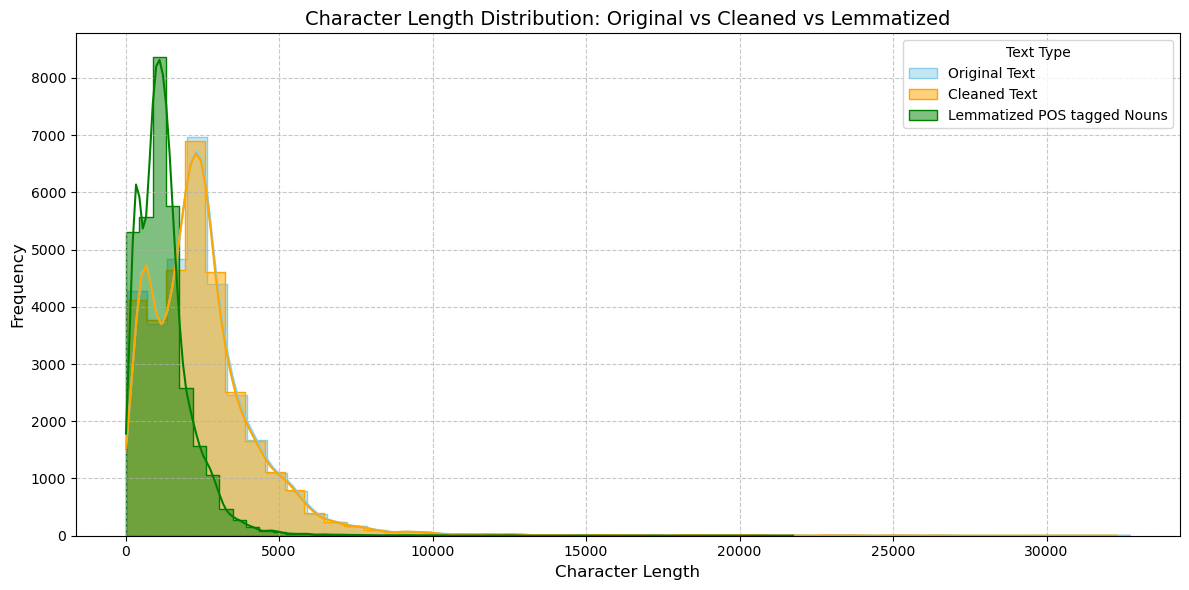

In [87]:
# Create a histogram plot to visualise character lengths
plt.figure(figsize=(12, 6))
sns.histplot(train_df['original_text_len'], color='skyblue', label='Original Text', kde=True, bins=50, alpha=0.5, element="step")
# Add histogram for cleaned news text
sns.histplot(train_df['cleaned_text_len'], color='orange', label='Cleaned Text', kde=True, bins=50, alpha=0.5, element="step")
# Add histogram for lemmatized news text with POS tags removed
sns.histplot(train_df['processed_text_len'], color='green', label='Lemmatized POS tagged Nouns', kde=True, bins=50, alpha=0.5, element="step")

plt.title('Character Length Distribution: Original vs Cleaned vs Lemmatized', fontsize=14)
plt.xlabel('Character Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title="Text Type")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **4.2** Find and display the top 40 words by frequency among true and fake news in Training data after processing the text  <font color = red>[10 marks]</font> <br>



##### 4.2.1 Find and display the top 40 words by frequency among true news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

{"state'": 1.0, "year'": 0.9909368535119693, "government'": 0.8766623977933209, "country'": 0.6545167963747414, "people'": 0.6400354644862575, "trump'": 0.5812235247758841, "week'": 0.555708797162841, "month'": 0.5406363905033987, "time'": 0.524578859225692, "group'": 0.424194660624569, "statement'": 0.4124716776672249, "official'": 0.39808885824056744, "day'": 0.3887301743670574, "president' donald'": 0.35612254950251204, "issue'": 0.3235149246379667, "monday'": 0.31445177814993597, "law'": 0.31021574229139987, "tuesday'": 0.30785144320756574, "part'": 0.29888680918136146, "leader'": 0.2970150724066594, "party'": 0.29632548517387447, "wednesday'": 0.2941582110136932, "plan'": 0.28253374051817554, "way'": 0.27366761895379765, "donald' trump'": 0.2691360457097823, "policy'": 0.26706728401142743, "friday'": 0.266968771549601, "election'": 0.2618461235346271, "thursday'": 0.2585952122943552, "china'": 0.25810264998522314, "company'": 0.25770860013791747, "decision'": 0.2556398384395626, "

<Figure size 1200x600 with 0 Axes>

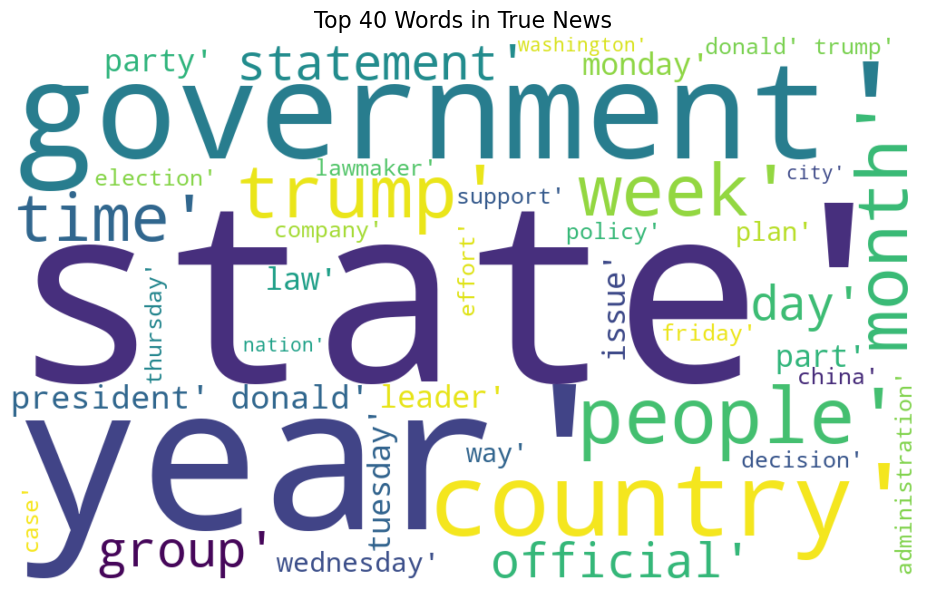

In [105]:
## Use a word cloud find the top 40 words by frequency among true news in the training data after processing the text
from wordcloud import WordCloud
# Filter news with label 1 (True News) and convert to it string and handle any non-string values

# Generate word cloud for True News
train_true_df = train_df[train_df['news_label'] == 1].copy()
all_text = ' '.join(train_true_df['processed_text'])

# Generate word cloud for True News
wordcloud = WordCloud(width=1000, height=600,
                      background_color='white',
                      max_words=40,
                      colormap='viridis').generate(all_text)
print(wordcloud.words_)
# Display the WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 Words in True News", fontsize=16)
plt.tight_layout()
plt.show()

##### 4.2.2 Find and display the top 40 words by frequency among fake news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

{"trump'": 1.0, "people'": 0.893629585886174, "time'": 0.715804237100465, "year'": 0.6622868531778253, "president'": 0.5444747914667454, "state'": 0.4661548682365099, "way'": 0.4363327674023769, "day'": 0.40599394699933566, "clinton'": 0.40023621466007236, "country'": 0.39499520188971726, "medium'": 0.36140842991068134, "thing'": 0.34775226987524915, "woman'": 0.34369233040525576, "government'": 0.32826456041928104, "twitter' com'": 0.31888979109766, "fact'": 0.3186683398538422, "video'": 0.3154942053591201, "house'": 0.3075219605816786, "news'": 0.28943677566989, "man'": 0.28190743338008417, "week'": 0.27880711596663466, "america'": 0.2703919687015575, "report'": 0.2581383332103049, "obama'": 0.2508304421643168, "group'": 0.2508304421643168, "party'": 0.25031372259540857, "pic' twitter'": 0.24344873403705616, "american'": 0.24330109987451096, "donald' trump'": 0.24101277035506016, "today'": 0.24064368494869712, "statement'": 0.23865062375433677, "president' trump'": 0.2385768066730641

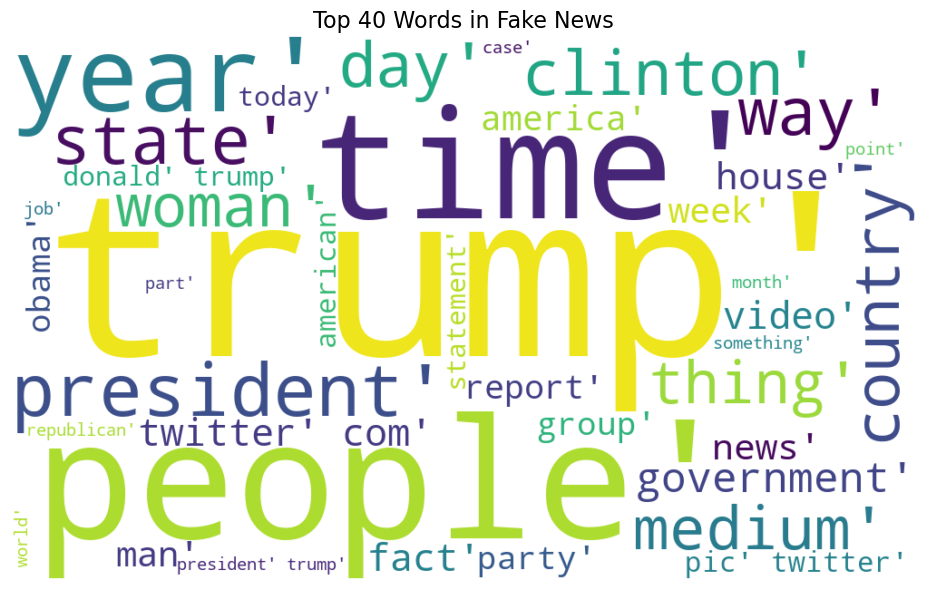

In [107]:
## Use a word cloud find the top 40 words by frequency among fake news in the training data after processing the text

# Filter news with label 0 (Fake News) and convert to it string and handle any non-string values
train_fake_df = train_df[train_df['news_label'] == 0].copy()
all_text = ' '.join(train_fake_df['processed_text'])
# Generate word cloud for Fake News
wordcloud = WordCloud(width=1000, height=600,
                      background_color='white',
                      max_words=40,
                      colormap='viridis').generate(all_text)
print(wordcloud.words_)
# Display the WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 Words in Fake News", fontsize=16)
plt.tight_layout()
plt.show()

### **4.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  <font color = red>[20 marks]</font> <br>




##### 4.3.1 Write a function to get the specified top n-grams  <font color = red>[4 marks]</font> <br>



In [109]:
# Write a function to get the specified top n-grams
true_news = train_df[train_df['news_label'] == 1]['processed_text']
fake_news = train_df[train_df['news_label'] == 0]['processed_text']

def plot_ngrams(corpus, ngram_range=(1,1), top_n=20, title='', color='skyblue'):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    word_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:top_n]
    print("word_freq: ",word_freq)
    # Convert to DataFrame for easy plotting
    df_ngram = pd.DataFrame(word_freq, columns=['n-gram', 'frequency'])
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(df_ngram['n-gram'][::-1], df_ngram['frequency'][::-1], color=color)
    plt.title(title, fontsize=14)
    plt.xlabel('Frequency')
    plt.tight_layout()
    plt.show()

true_corpus = true_news.tolist()
fake_corpus = fake_news.tolist()

##### 4.3.2 Handle the NaN values  <font color = red>[1 mark]</font> <br>



In [111]:
# Handle NaN values in the text data
true_news = train_df[train_df['news_label'] == 1]['processed_text'].fillna("")
fake_news = train_df[train_df['news_label'] == 0]['processed_text'].fillna("")

# Convert Series to list
true_corpus = true_news.tolist()
fake_corpus = fake_news.tolist()

### For True News




##### 4.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

word_freq:  [('trump', 32880), ('state', 26278), ('president', 20407), ('reuters', 17187), ('year', 15883), ('government', 14165), ('house', 12838), ('people', 10911), ('party', 10820), ('election', 10502)]


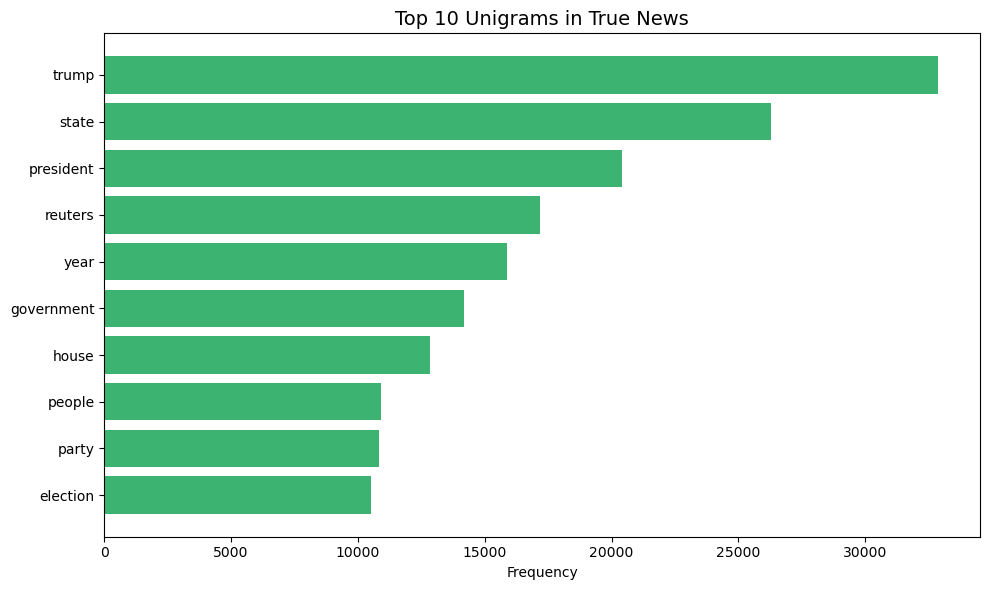

In [113]:
# Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
plot_ngrams(true_corpus, (1,1), 10, "Top 10 Unigrams in True News", 'mediumseagreen')

##### 4.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



word_freq:  [('president donald', 3615), ('donald trump', 2744), ('washington reuters', 2350), ('reuters president', 2161), ('president barack', 2003), ('barack obama', 1981), ('secretary state', 1682), ('house representative', 1593), ('state department', 1412), ('trump administration', 1324)]


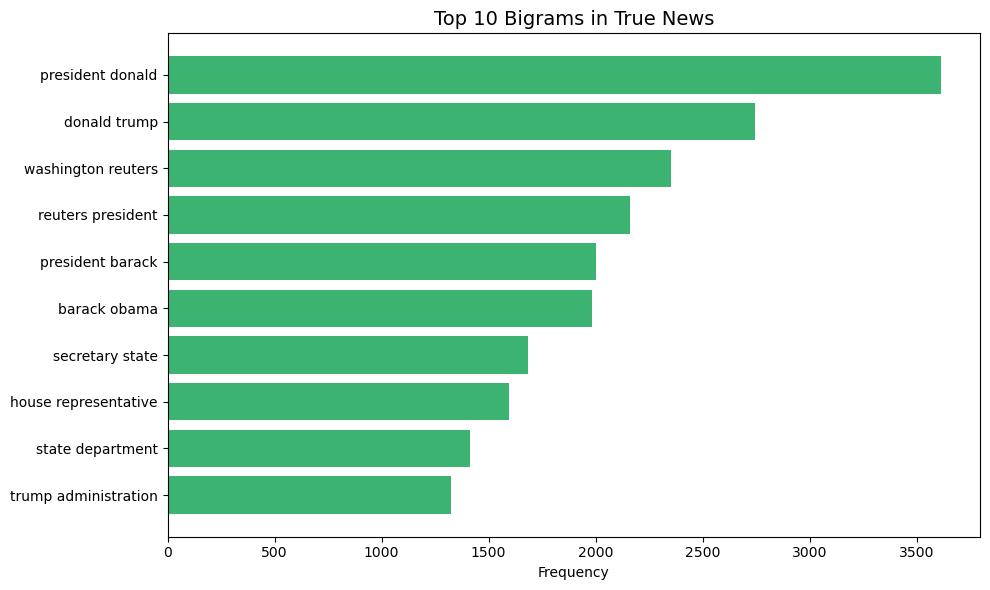

In [115]:
# Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
plot_ngrams(true_corpus, (2,2), 10, "Top 10 Bigrams in True News", 'mediumseagreen')

##### 4.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



word_freq:  [('president barack obama', 1780), ('president donald trump', 1692), ('reuters president donald', 920), ('washington reuters president', 775), ('secretary state rex', 490), ('state rex tillerson', 466), ('president vladimir putin', 457), ('speaker paul ryan', 366), ('leader mitch mcconnell', 336), ('chancellor angela merkel', 325)]


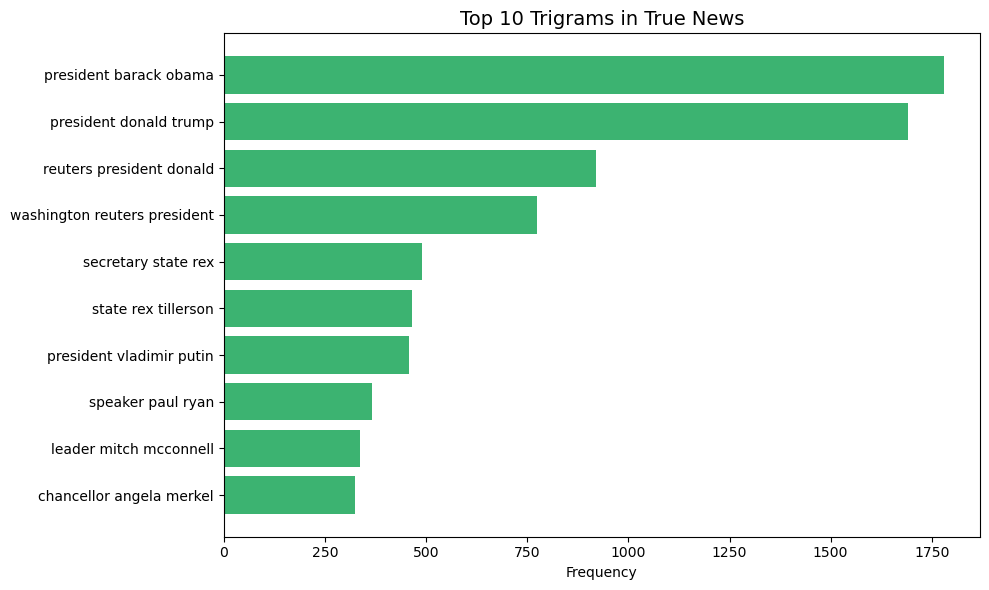

In [117]:
# Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
plot_ngrams(true_corpus, (3,3), 10, "Top 10 Trigrams in True News", 'mediumseagreen')

### For Fake News







##### 4.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

word_freq:  [('trump', 49819), ('president', 20260), ('people', 19072), ('state', 16076), ('year', 13587), ('time', 13430), ('clinton', 13272), ('news', 10496), ('image', 10094), ('obama', 9084)]


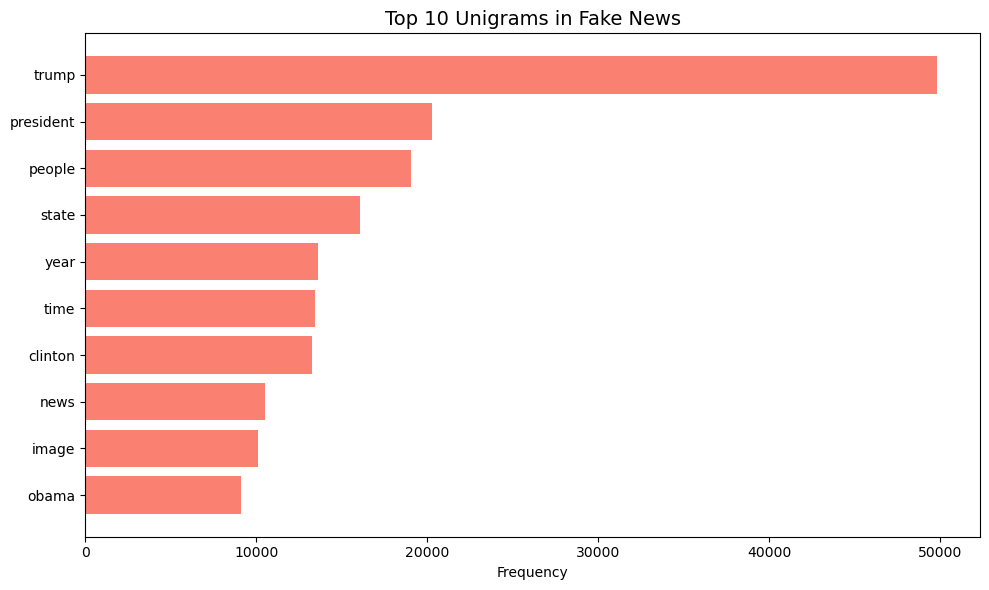

In [119]:
# Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
plot_ngrams(fake_corpus, (1,1), 10, "Top 10 Unigrams in Fake News", 'salmon')

##### 4.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



word_freq:  [('twitter com', 4320), ('donald trump', 3981), ('pic twitter', 3298), ('president trump', 3233), ('getty image', 2245), ('president obama', 1888), ('trump supporter', 1449), ('trump campaign', 1435), ('barack obama', 1336), ('century wire', 1324)]


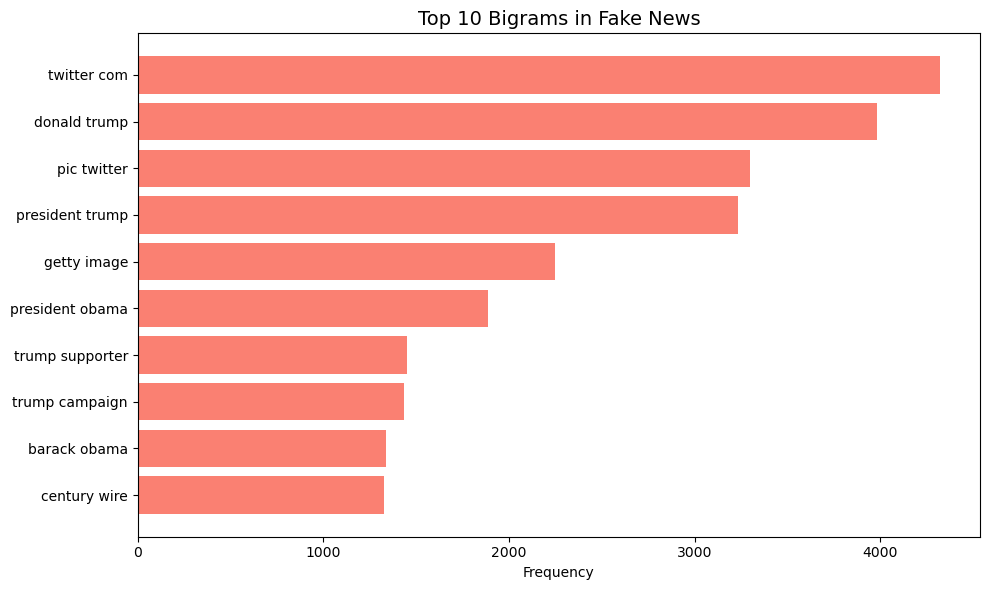

In [121]:
# Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
plot_ngrams(fake_corpus, (2,2), 10, "Top 10 Bigrams in Fake News", 'salmon')

##### 4.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



word_freq:  [('pic twitter com', 3105), ('news century wire', 657), ('president barack obama', 588), ('donald trump realdonaldtrump', 582), ('image video screen', 417), ('video screen capture', 395), ('president donald trump', 366), ('co pic twitter', 339), ('chip somodevilla getty', 289), ('somodevilla getty image', 284)]


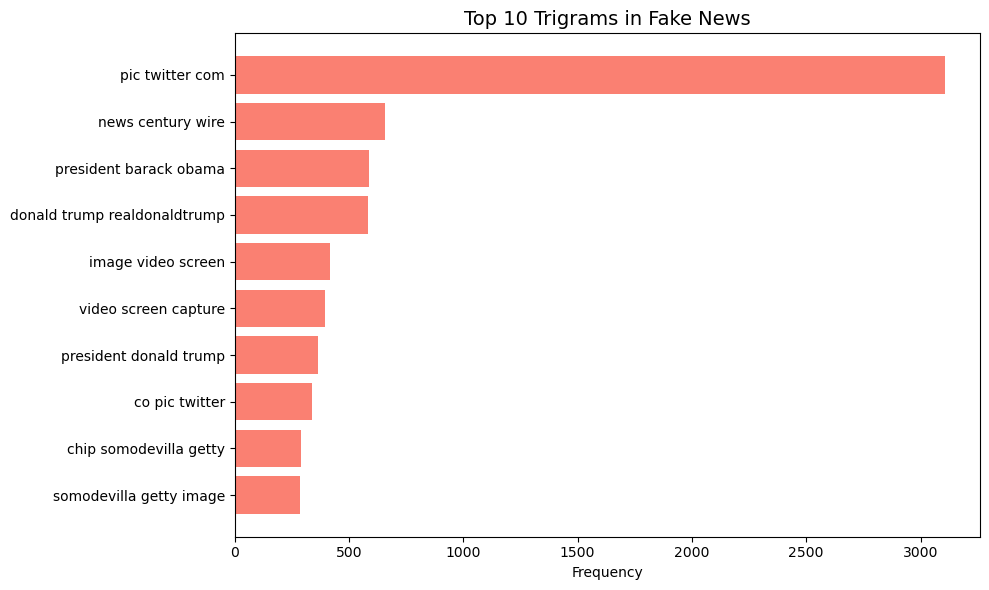

In [123]:
# Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
plot_ngrams(fake_corpus, (3,3), 10, "Top 10 Trigrams in Fake News", 'salmon')

## **5.** Exploratory Data Analysis on Validation Data [Optional]

Perform EDA on validation data to differentiate EDA on training data with EDA on validation data and the tasks are given below:

<ul>
  <li> Visualise the data according to the character length of cleaned news text and lemmatized text with POS tags removed
  <li> Using a word cloud find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **5.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed

##### 5.1.1  Add new columns to calculate the character lengths of the processed data columns

In [125]:
# Add a new column to calculate the character length of cleaned news text
val_df['origianl_text_len'] = val_df['news_text'].str.len()
# Add a new column to calculate the character length of lemmatized news text with POS tags removed
val_df['cleaned_text_len'] = val_df['cleaned_text'].str.len()
val_df['processed_text_len'] = val_df['processed_text'].str.len()
val_df.head(5)

news_text  \
22216  Trump aides differ over Assad's future after Syria attack WASHINGTON (Reuters) - Top aides to President Donald Trump demurred on Sunday over where U.S. policy on Syria was headed after last week’s retaliatory missile strike, leaving open questions about whether removing Syrian leader Bashar al-Assad from power was now one of Trump’s goals. After the United States launched cruise missile strikes on a Syrian air base alleged to have launched a deadly poison gas attack on Syrian civilians, Trump administration officials said they were prepared to take further actions if necessary. Trump’s United Nations ambassador, Nikki Haley, said the United States had “multiple priorities” in Syria and that stability there was impossible with Assad as president. “In no way do we see peace in that area with Assad as the head of the Syrian government,” Haley told NBC’s “Meet the Press.” “And we have to make sure that we’re pushing that process. The political solution has to come together for the good of the people of Syria,” she said. Her comments appeared at odds with those of Secretary of State Rex Tillerson, who said the U.S. missile strike was aimed solely at deterring the use of chemical weapons by Assad. “There is no change to our military posture” in Syria, Tillerson said on ABC’s ‘This Week’ program. Tillerson said the U.S. priority in Syria was defeating Islamic State, the militant group also known as ISIS. Once ISIS is defeated, the United States could turn its attention to trying to help bring about a “political process” that could bring about stability in Syria, he said. “It is through that political process that we believe the Syrian people will ... be able to decide the fate of Bashar al-Assad,” Tillerson said. A White House official, speaking on condition of anonymity, said any difference in nuance was inadvertent and unintentional, and declined to comment further. During the 2016 presidential campaign, Trump said defeating Islamic State was a higher priority than persuading Assad to step down. The Republican criticized calls by his Democratic opponent, Hillary Clinton, for the establishment of a no-fly zone and “safe zones” to protect non-combatants. “What we should do is focus on ISIS. We should not be focusing on Syria,” Trump told Reuters in an interview last October. Tillerson on Sunday blamed Russia for enabling the poison gas attack by failing to follow through on a 2013 agreement to secure and destroy chemical weapons stockpiles in Syria. “The failure related to the recent strike and the recent terrible chemical weapons attack in large measure is a failure on Russia’s part to achieve its commitment to the international community,” he added. Russia swiftly condemned last week’s attack. On Sunday, a joint command center comprised of Russian, Iranian and militia forces supporting Assad said it would respond to any new aggression and increase its support for its ally. Trump ordered the missile strikes on the Syrian air base after blaming Assad for the chemical weapons attack, which killed at least 70 people, many of them children, in the Syrian town of Khan Sheikhoun. The Syrian government has denied it was behind the assault. Speaking on “Fox News Sunday,” White House national security adviser H.R. McMaster said the United States was “prepared to do more” regarding military action in Syria if necessary. On whether Assad should be removed from power, McMaster said: “We are not saying that we are the ones who are going to effect that change. “What we are saying is other countries have to ask themselves some hard questions. Russia should ask themselves, ‘What are we doing here?’” McMaster said. Lawmakers from both the Democratic and Republican parties were supportive of Trump’s decision to attack the Syrian air base, but some Republican senators said they were concerned about the lack of policy clarity and Tillerson’s strategy of leaving Assad’s fate unresolved while concentrating on Islamic State. “There see

##### 5.1.2  Create Histogram to visualise character lengths

Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

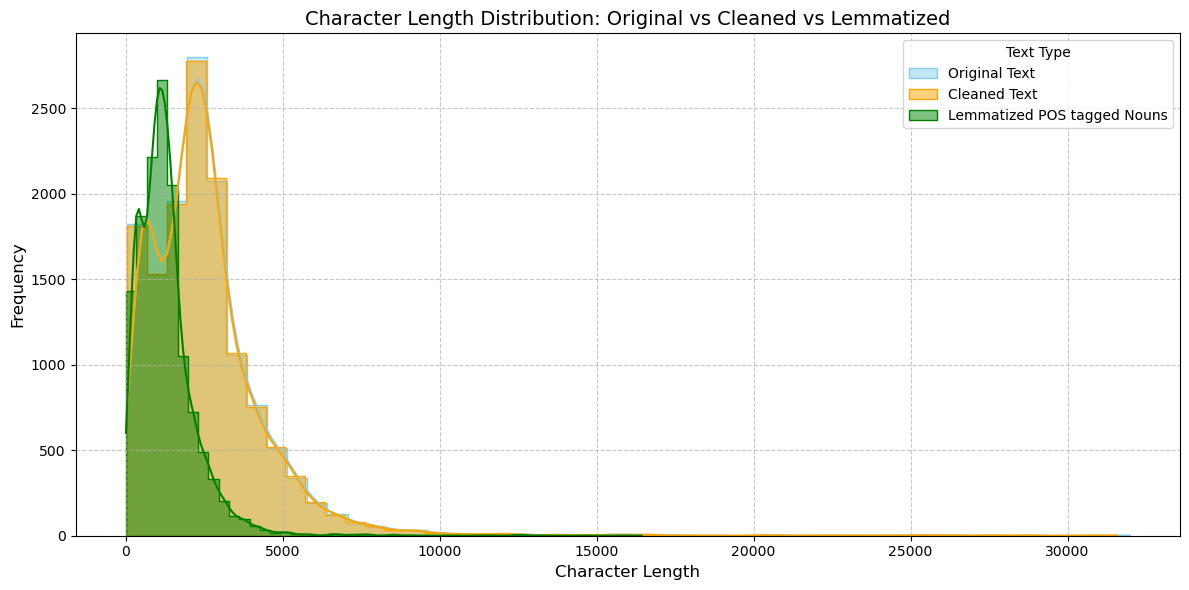

In [127]:
plt.figure(figsize=(12, 6))

# Create a histogram plot to visualise character lengths 
sns.histplot(val_df['origianl_text_len'], color='skyblue', label='Original Text', kde=True, bins=50, alpha=0.5, element="step")
# Add histogram for cleaned news text
sns.histplot(val_df['cleaned_text_len'], color='orange', label='Cleaned Text', kde=True, bins=50, alpha=0.5, element="step")
# Add histogram for lemmatized news text with POS tags removed
sns.histplot(val_df['processed_text_len'], color='green', label='Lemmatized POS tagged Nouns', kde=True, bins=50, alpha=0.5, element="step")

plt.title('Character Length Distribution: Original vs Cleaned vs Lemmatized', fontsize=14)
plt.xlabel('Character Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title="Text Type")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **5.2** Find and display the top 40 words by frequency among true and fake news after processing the text

##### 5.2.1  Find and display the top 40 words by frequency among true news in validation data after processing the text

{"state'": 1.0, "trump'": 0.8225114416475973, "year'": 0.7796052631578947, "government'": 0.6872139588100686, "country'": 0.5300343249427918, "people'": 0.504433638443936, "week'": 0.42162471395881007, "time'": 0.3805778032036613, "official'": 0.36713386727688785, "month'": 0.36441647597254007, "party'": 0.3392448512585812, "group'": 0.335383295194508, "statement'": 0.29805491990846683, "president'": 0.29390732265446223, "election'": 0.2867562929061785, "day'": 0.27145308924485123, "law'": 0.2477116704805492, "tuesday'": 0.2465675057208238, "issue'": 0.2431350114416476, "monday'": 0.2391304347826087, "house'": 0.2351258581235698, "thursday'": 0.23355263157894737, "policy'": 0.23083524027459953, "leader'": 0.22640160183066363, "wednesday'": 0.22325514874141877, "friday'": 0.2219679633867277, "vote'": 0.2138157894736842, "reuters'": 0.21310068649885583, "support'": 0.21052631578947367, "part'": 0.20823798627002288, "plan'": 0.2080949656750572, "president' donald'": 0.2069508009153318, "c

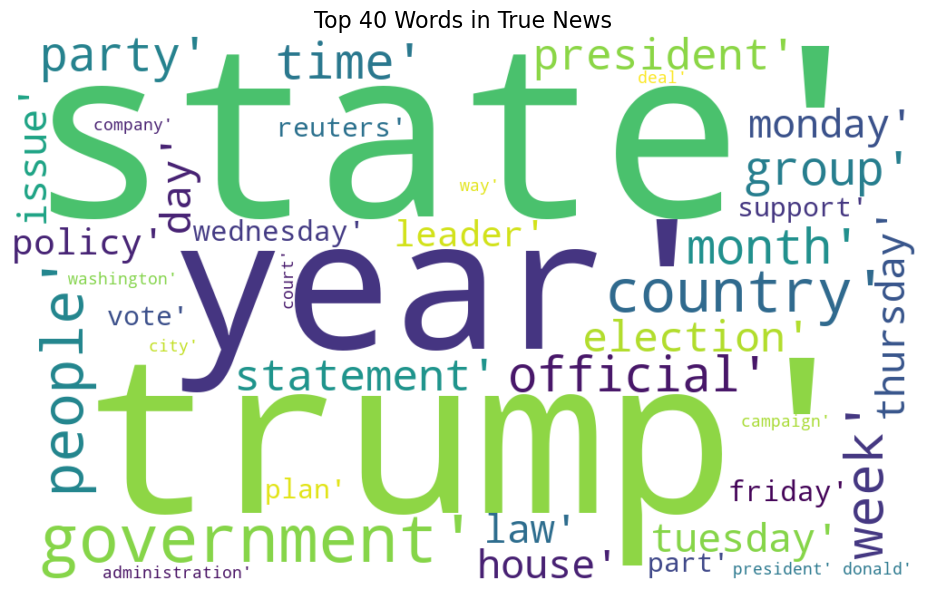

In [129]:
## Use a word cloud find the top 40 words by frequency among true news after processing the text
val_true_df = val_df[val_df['news_label'] == 1].copy()
all_text = ' '.join(val_true_df['processed_text'])

# Generate word cloud for True News
wordcloud = WordCloud(width=1000, height=600,
                      background_color='white',
                      max_words=40,
                      colormap='viridis').generate(all_text)
print(wordcloud.words_)
# Display the WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 Words in True News", fontsize=16)
plt.tight_layout()
plt.show()

##### 5.2.2  Find and display the top 40 words by frequency among fake news in validation data after processing the text

{"trump'": 1.0, "people'": 0.5937946131150661, "time'": 0.4398972113828876, "year'": 0.4194346626058818, "president'": 0.39716379556486153, "state'": 0.3442466926810698, "clinton'": 0.3090320738555249, "country'": 0.26810697630151326, "way'": 0.2526886837346531, "medium'": 0.24383744170552965, "day'": 0.23460550109450842, "thing'": 0.227467402683925, "woman'": 0.22451698867421718, "house'": 0.2216617493099838, "government'": 0.2055772342248025, "news'": 0.20272199486056913, "fact'": 0.2024364709241458, "video'": 0.19891500904159132, "week'": 0.17826211097363662, "man'": 0.17036261539925765, "party'": 0.17017226610830874, "america'": 0.16331969163414867, "twitter' com'": 0.15998857904254307, "group'": 0.1579899114875797, "report'": 0.15703816503283524, "campaign'": 0.15494432283239745, "obama'": 0.15475397354144857, "world'": 0.15456362425049966, "american'": 0.15456362425049966, "case'": 0.1485676215856096, "family'": 0.14390406395736177, "statement'": 0.14181022175692395, "election'":

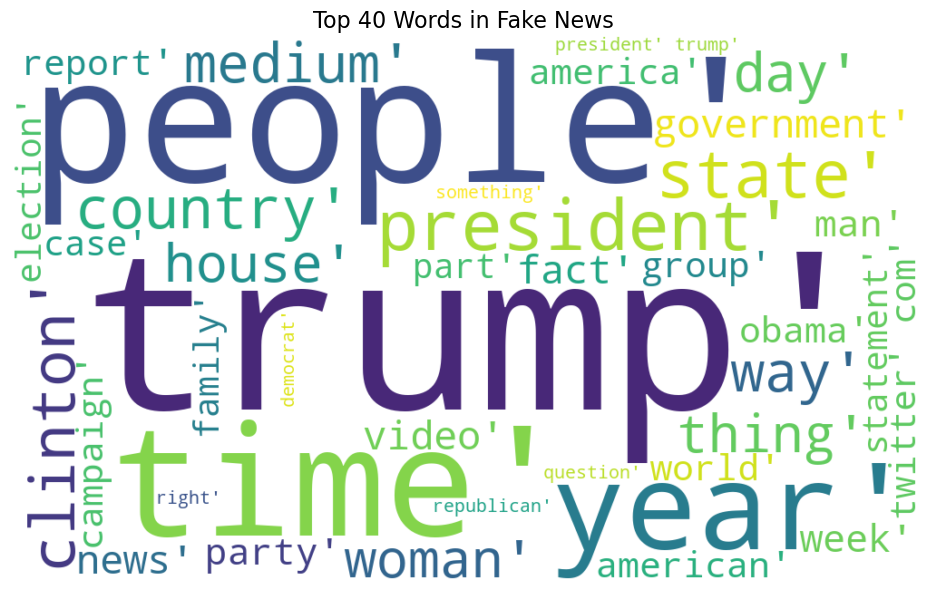

In [131]:
## Use a word cloud find the top 40 words by frequency among fake news after processing the text

val_fake_df = val_df[val_df['news_label'] == 0].copy()
all_text = ' '.join(val_fake_df['processed_text'])

# Generate word cloud for Fake News
wordcloud = WordCloud(width=1000, height=600,
                      background_color='white',
                      max_words=40,
                      colormap='viridis').generate(all_text)
print(wordcloud.words_)
# Display the WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 Words in Fake News", fontsize=16)
plt.tight_layout()
plt.show()

### **5.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  





##### 5.3.1 Write a function to get the specified top n-grams

In [133]:
## Write a function to get the specified top n-grams
true_news = val_df[val_df['news_label'] == 1]['processed_text']
fake_news = val_df[val_df['news_label'] == 0]['processed_text']

def plot_ngrams(corpus, ngram_range=(1,1), top_n=20, title='', color='skyblue'):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    word_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:top_n]
    print("word_freq: ",word_freq)
    # Convert to DataFrame for easy plotting
    df_ngram = pd.DataFrame(word_freq, columns=['n-gram', 'frequency'])
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(df_ngram['n-gram'][::-1], df_ngram['frequency'][::-1], color=color)
    plt.title(title, fontsize=14)
    plt.xlabel('Frequency')
    plt.tight_layout()
    plt.show()

true_corpus = true_news.tolist()
fake_corpus = fake_news.tolist()

##### 5.3.2 Handle the NaN values

In [135]:
## First handle NaN values in the text data
true_news = val_df[val_df['news_label'] == 1]['processed_text'].fillna("")
fake_news = val_df[val_df['news_label'] == 0]['processed_text'].fillna("")

# Convert Series to list
true_corpus = true_news.tolist()
fake_corpus = fake_news.tolist()

### For True News



##### 5.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph

word_freq:  [('trump', 13921), ('state', 11483), ('president', 8847), ('reuters', 7638), ('year', 6990), ('government', 6247), ('house', 5643), ('election', 4913), ('party', 4890), ('people', 4546)]


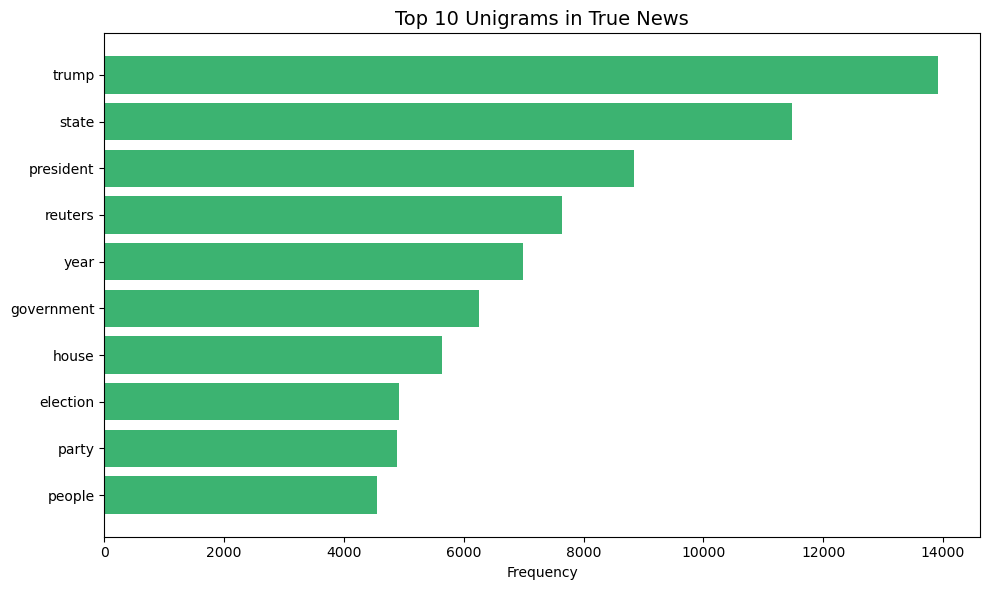

In [137]:
## Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
plot_ngrams(true_corpus, (1,1), 10, "Top 10 Unigrams in True News", 'mediumseagreen')

##### 5.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph

word_freq:  [('president donald', 1447), ('donald trump', 1149), ('washington reuters', 978), ('reuters president', 936), ('president barack', 849), ('barack obama', 843), ('house representative', 680), ('secretary state', 679), ('trump campaign', 611), ('trump administration', 582)]


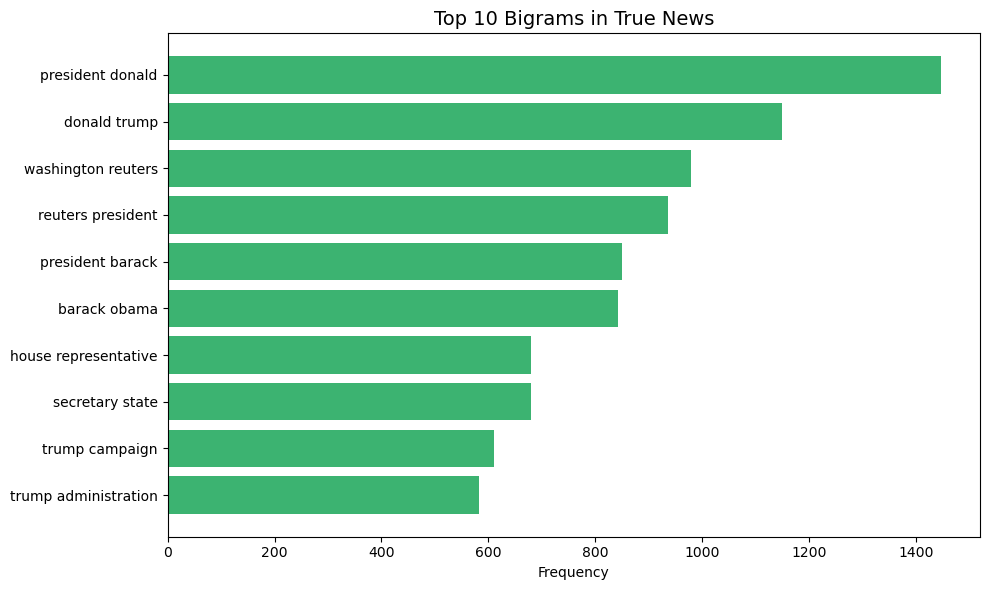

In [139]:
## Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
plot_ngrams(true_corpus, (2,2), 10, "Top 10 Bigrams in True News", 'mediumseagreen')

##### 5.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph

word_freq:  [('president barack obama', 748), ('president donald trump', 664), ('reuters president donald', 376), ('washington reuters president', 305), ('president vladimir putin', 208), ('secretary state rex', 182), ('state rex tillerson', 178), ('speaker paul ryan', 161), ('leader mitch mcconnell', 155), ('majority leader mitch', 148)]


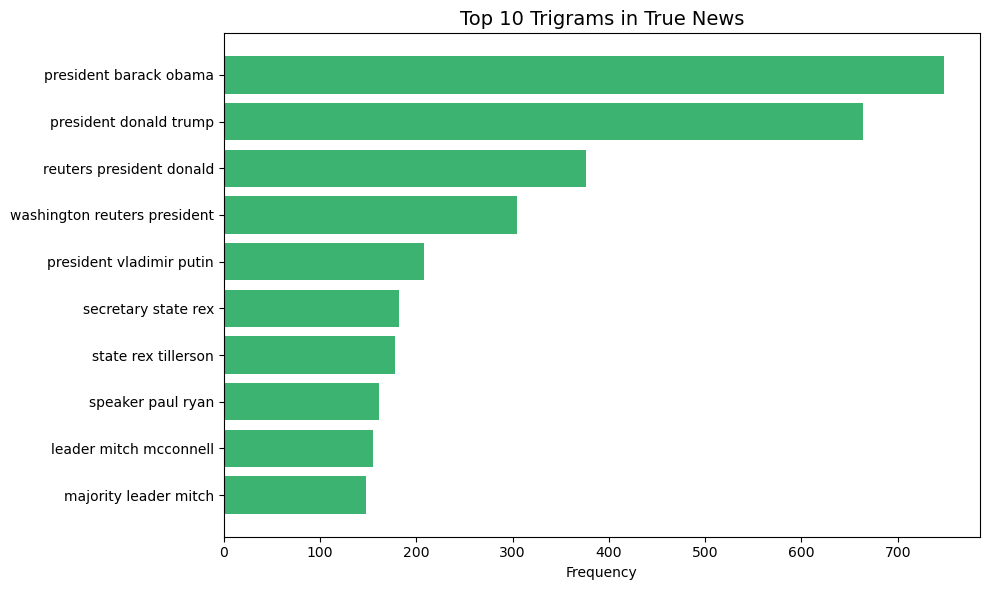

In [141]:
## Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
plot_ngrams(true_corpus, (3,3), 10, "Top 10 Trigrams in True News", 'mediumseagreen')

### For Fake News

##### 5.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph

word_freq:  [('trump', 22047), ('president', 9011), ('people', 7922), ('state', 6883), ('clinton', 6027), ('time', 5795), ('year', 5702), ('news', 4720), ('image', 4441), ('campaign', 3756)]


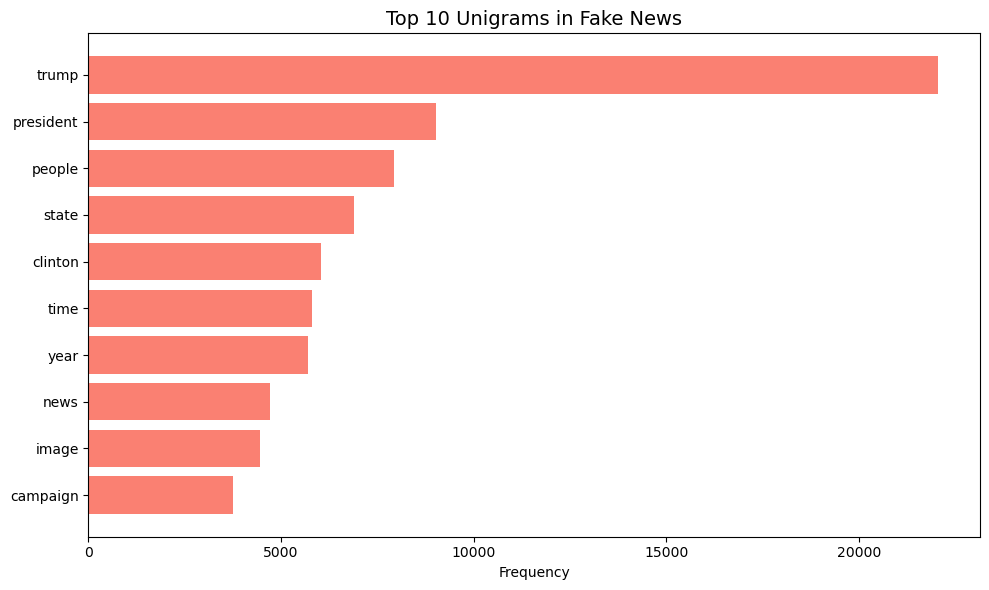

In [143]:
## Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
plot_ngrams(fake_corpus, (1,1), 10, "Top 10 Unigrams in Fake News", 'salmon')

##### 5.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph

word_freq:  [('twitter com', 1681), ('donald trump', 1635), ('president trump', 1435), ('pic twitter', 1295), ('getty image', 983), ('president obama', 902), ('trump campaign', 716), ('trump supporter', 610), ('century wire', 556), ('state department', 520)]


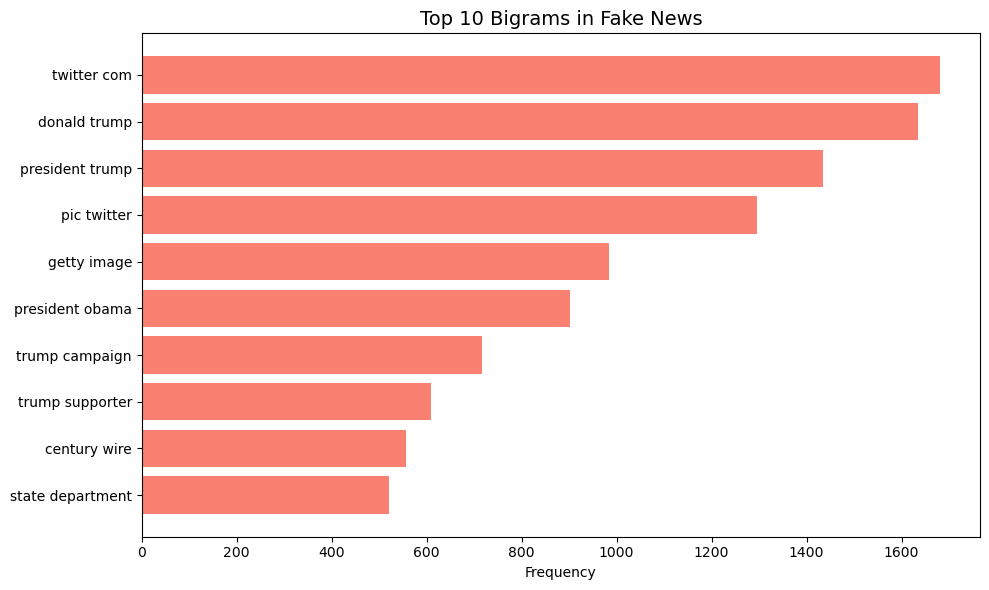

In [145]:
## Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
plot_ngrams(fake_corpus, (2,2), 10, "Top 10 Bigrams in Fake News", 'salmon')

##### 5.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph

word_freq:  [('pic twitter com', 1206), ('news century wire', 272), ('donald trump realdonaldtrump', 224), ('president barack obama', 215), ('image video screen', 178), ('video screen capture', 168), ('president donald trump', 145), ('chip somodevilla getty', 135), ('somodevilla getty image', 133), ('co pic twitter', 129)]


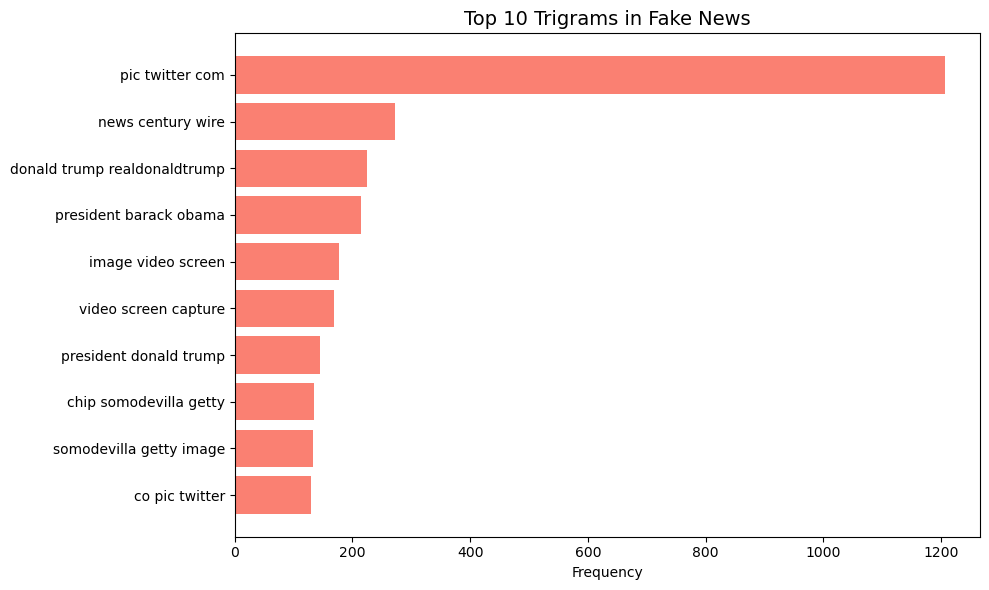

In [147]:
## Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
plot_ngrams(fake_corpus, (3,3), 10, "Top 10 Trigrams in Fake News", 'salmon')

## **6.** Feature Extraction  <font color = red>[10 marks]</font> <br>

For any ML model to perform classification on textual data, you need to convert it to a vector form. In this assignment, you will use the Word2Vec Vectorizer to create vectors from textual data. Word2Vec model captures the semantic relationship between words.


### **6.1** Initialise Word2Vec model  <font color = red>[2 marks]</font>

In [151]:
## Write your code here to initialise the Word2Vec model by downloading "word2vec-google-news-300"
import gensim.downloader as api

w2v_model = api.load('word2vec-google-news-300')

In [153]:
y_train.head()

13970    1
41668    1
26810    1
30967    0
26072    0
Name: news_label, dtype: int64

### **6.2** Extract vectors for cleaned news data   <font color = red>[8 marks]</font>

In [155]:
## Write your code here to extract the vectors from the Word2Vec model for both training and validation data
def vector_ducs(tokens, model):
    vectores = [model[word] for word in tokens if word in model]
    if not vectores:
        return np.zeros(model.vector_size, dtype=float)
    return np.mean(vectores, axis=0)

X_train_vector = np.vstack(X_train["processed_text"].apply(lambda x: vector_ducs(x, w2v_model)))
X_val_vector = np.vstack(X_val["processed_text"].apply(lambda x: vector_ducs(x, w2v_model)))

## Extract the target variable for the training data and validation data

print("X_train_vec shape:", X_train_vector.shape)  
print("X_val_vec shape:",   X_val_vector.shape)     
print("y_train shape:",     y_train.shape)      
print("y_val shape:",       y_val.shape)  


X_train_vec shape: (31428, 300)
X_val_vec shape: (13470, 300)
y_train shape: (31428,)
y_val shape: (13470,)


## **7.** Model Training and Evaluation <font color = red>[45 marks]</font>

You will use a set of supervised models to classify the news into true or fake.

### **7.0** Import models and evaluation metrics

In [157]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

### **7.1** Build Logistic Regression Model  <font color = red>[15 marks]</font>

##### 7.1.1 Create and train logistic regression model on training data  <font color = red>[10 marks]</font>

In [159]:
## Initialise Logistic Regression model
logisticreg = LogisticRegression(max_iter=1000)
## Train Logistic Regression model on training data
logisticreg.fit(X_train_vector, y_train)
## Predict on validation 
y_pred_lr = logisticreg.predict(X_val_vector)


##### 7.1.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [161]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
accuracy  = accuracy_score(y_val, y_pred_lr)
precision = precision_score(y_val, y_pred_lr)
recall    = recall_score(y_val, y_pred_lr)
f1        = f1_score(y_val, y_pred_lr)

# 2. Print the scores
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.7111
Precision: 0.7058
Recall   : 0.6834
F1-Score : 0.6944


In [163]:
# Classification Report
print(classification_report(y_val, y_pred_lr))

              precision    recall  f1-score   support

           0       0.72      0.74      0.73      7001
           1       0.71      0.68      0.69      6469

    accuracy                           0.71     13470
   macro avg       0.71      0.71      0.71     13470
weighted avg       0.71      0.71      0.71     13470



### **7.2** Build Decision Tree Model <font color = red>[15 marks]</font>

##### 7.2.1 Create and train a decision tree model on training data <font color = red>[10 marks]</font>

In [165]:
## Initialise Decision Tree model
decision_tree = DecisionTreeClassifier(random_state=42)

## Train Decision Tree model on training data
decision_tree.fit(X_train_vector, y_train)

## Predict on validation data
y_pred_dt = decision_tree.predict(X_val_vector)


##### 7.2.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [167]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
accuracy  = accuracy_score(y_val, y_pred_dt)
precision = precision_score(y_val, y_pred_dt)
recall    = recall_score(y_val, y_pred_dt)
f1        = f1_score(y_val, y_pred_dt)

# 2. Print the scores
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.7081
Precision: 0.7110
Recall   : 0.6608
F1-Score : 0.6850


In [169]:
# Classification Report
print(classification_report(y_val, y_pred_dt))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73      7001
           1       0.71      0.66      0.68      6469

    accuracy                           0.71     13470
   macro avg       0.71      0.71      0.71     13470
weighted avg       0.71      0.71      0.71     13470



### **7.3** Build Random Forest Model <font color = red>[15 marks]</font>


##### 7.3.1 Create and train a random forest model on training data <font color = red>[10 marks]</font>

In [171]:
## Initialise Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=200,      
    max_depth=15,        
    random_state=42,
    n_jobs=-1              
)
## Train Random Forest model on training data
random_forest.fit(X_train_vector, y_train)

## Predict on validation data
y_pred_rf = random_forest.predict(X_val_vector)


 ##### 7.3.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [173]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
accuracy  = accuracy_score(y_val, y_pred_rf)
precision = precision_score(y_val, y_pred_rf)
recall    = recall_score(y_val, y_pred_rf)
f1        = f1_score(y_val, y_pred_rf)


print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.7955
Precision: 0.7888
Recall   : 0.7842
F1-Score : 0.7865


In [175]:
# Classification Report
print(classification_report(y_val, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      7001
           1       0.79      0.78      0.79      6469

    accuracy                           0.80     13470
   macro avg       0.80      0.80      0.80     13470
weighted avg       0.80      0.80      0.80     13470



## **8.** Conclusion <font color = red>[5 marks]</font>

Summarise your findings by discussing patterns observed in true and fake news and how semantic classification addressed the problem. Highlight the best model chosen, the evaluation metric prioritised for the decision, and assess the approach and its impact.

- **Logistic Regression:** <span style="color:orange; font-weight:bold">~71% Accuracy</span>, <span style="color:orange">F1 ≈ 0.69</span>  
- **Decision Tree:** <span style="color:red; font-weight:bold">Lower performance</span> compared to others  
- **Random Forest:** <span style="color:green; font-weight:bold">Best Model</span> with  
  - **Accuracy:** <span style="color:green">~80%</span>  
  - **Precision:** <span style="color:green">0.79</span>  
  - **Recall:** <span style="color:green">0.78</span>  
  - **F1-score:** <span style="color:green">0.79</span> 

In both the training and validation
* on sets, “state” and “trump” are among the most frequent words, likely reflecting election-related content.
* The prominence of names like “Obama” and “Trump” suggests the dataset was drawn from U.S. news around the 2016 election.
* Unigrams, bigrams, and trigrams effectively capture single words, two-word phrases, and three-word sequences, respectively.
* The Random Forest classifier outperforms both Logistic Regression and the Decision Tree models on this task.